## Load packages and Data

In [1]:
import warnings
from igraph import palettes
warnings.filterwarnings('ignore')
import os
import STAHD
# # the location of R (used for the mclust clustering)
import os
os.environ['R_HOME'] = "/usr/lib/R/"
os.environ['R_USER'] = "~/.conda/envs/STAligner/lib/python3.8/site-packages/rpy2"

import rpy2.robjects as robjects
import rpy2.robjects.numpy2ri
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg

import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

import scanpy as sc
import h5py

data_file = '/home/dwang/code/STAHI-minibatch/Visium_HD_Human_Breast_Cancer_FFPE_binned_outputs/square_008um/filtered_feature_bc_matrix.h5'

adata = sc.read_10x_h5(data_file)
print(adata)

coordinates = []

for name in adata.obs_names:

    parts = name.split('_')
    x_coord = int(parts[2])  
    y_coord = int(parts[3].split('-')[0]) 
    coordinates.append([x_coord, y_coord])

coordinates_array = np.array(coordinates)
adata.obsm['spatial'] = coordinates_array

AnnData object with n_obs × n_vars = 663857 × 18085
    var: 'gene_ids', 'feature_types', 'genome'


## Constructing the spatial network

In [2]:
# Constructing the spatial network
STAHD.Cal_Spatial_Net(adata, rad_cutoff=4) # the spatial network are saved in adata.uns[‘adj’]
# STAligner.Stats_Spatial_Net(adata) # plot the number of spatial neighbors
adata.uns['edgeList'] = np.nonzero(adata.uns['adj'])

# Normalization
# sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=3000)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", n_top_genes=5000)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata = adata[:, adata.var['highly_variable']]

------Calculating spatial graph...
The graph contains 28790304 edges, 663857 cells.
43.3682 neighbors per cell on average.


## Running STAHD

In [3]:
strna = STAHD.train_STAHD(adata, hidden_dims=[50, 30], verbose=True, batch_size=4096, device=used_device)

STAligner(
  (conv1): GATConv(5002, 50, heads=1)
  (conv2): GATConv(50, 30, heads=1)
  (conv3): GATConv(30, 50, heads=1)
  (conv4): GATConv(50, 5002, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [2:06:58<00:00, 15.24s/it]  


## Visualization

In [9]:
leiden_resolution = 0.03
sc.pp.neighbors(adata, use_rep='STAGATE', random_state=666)
sc.tl.leiden(adata, random_state=666, key_added="leiden", resolution=leiden_resolution)

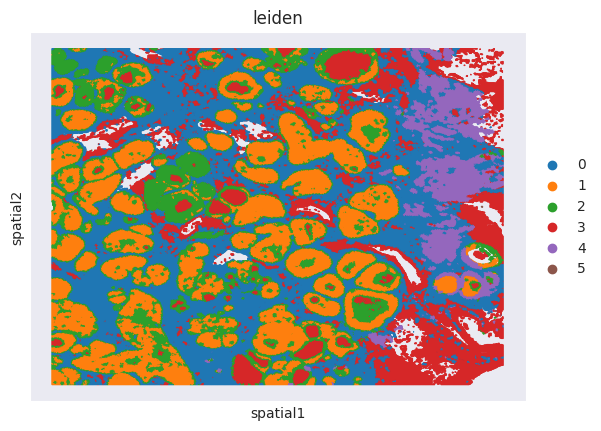

In [29]:
import scanpy as sc
sc.pl.embedding(adata, basis="spatial", color="leiden", show=False,s = 3)
adata.uns["kmeans_aligned_colors"] = adata.uns["leiden_colors"]